In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as colors

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [2]:
cd C:\Users\tr432\Downloads\filter_GutLungAxis_VNAM

C:\Users\tr432\Downloads\filter_GutLungAxis_VNAM


In [3]:
import pandas as pd

df_tax = pd.read_csv("gg2_genus_table.tsv", sep='\t', skiprows=1, index_col="#OTU ID")
df_tax["Total"] = df_tax.sum(axis=1)
df_tax = df_tax.sort_values("Total", ascending=False)

meta = pd.read_csv("RUN45_Metadata_GutLungAxis.txt", sep='\t')  ## csv일땐 sep='\t' 지워도 됨

print(df_tax.head(3))
print(meta.head(3))

                                                     V01-1w   V01-2w   V02-1w  \
#OTU ID                                                                         
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac...  22574.0  56608.0  53883.0   
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lact...     79.0     89.0    104.0   
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__B...    115.0    134.0     68.0   

                                                     V02-2w   V03-1w   V03-2w  \
#OTU ID                                                                         
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac...  66117.0  82456.0  55685.0   
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lact...     88.0   2998.0    161.0   
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__B...    117.0    153.0    160.0   

                                                     V04-1w   V04-2w   V05-0w  \
#OTU ID                                                                         
d__Bacteria;p__Pseudomonad

In [4]:
mapping = dict(zip(meta["#SampleID"].astype(str), meta["SamplingWeek"].astype(str)))

df_tax2 = df_tax.copy()
df_tax2.columns = [mapping.get(c, None) for c in df_tax.columns[0:]]

df_tax2 = df_tax2.loc[:, [c for c in df_tax2.columns if c is not None]]

grouped = df_tax2.set_index(df_tax2.index).T.groupby(level=0).mean().T

grouped["Total"] = df_tax["Total"]

grouped

,Week0,Week1,Week2,Total
#OTU ID,,,,
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029;__,160.333333,54615.9,60667.5,1153796.0
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Lactobacillaceae;g__Ligilactobacillus,27781.666667,2282.6,5115.1,240667.0
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Phocaeicola_A,20384.833333,219.9,125.4,125762.0
d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Lachnospirales;f__Lachnospiraceae;__,8040.500000,68.2,6.4,48989.0
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Tannerellaceae;g__Parabacteroides_B_862066,757.666667,3482.3,21.7,39586.0
...,...,...,...,...
d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Eubacteriales;f__Eubacteriaceae;g__Eubacterium_O_258270,0.000000,0.2,0.0,2.0
d__Bacteria;p__Actinomycetota;c__Actinomycetes;o__Actinomycetales;f__Dermabacteraceae;g__Brachybacterium,0.000000,0.2,0.0,2.0
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Lactobacillaceae;g__Liquorilactobacillus,0.000000,0.2,0.0,2.0


In [5]:
for col in grouped.columns:
    print(col, sum(grouped[col]))

Week0 92293.33333333333
Week1 65312.0
Week2 69689.5
Total 1903775.0


In [6]:
grouped.reset_index(inplace=True)
grouped

#grouped.to_csv("gg2_genus_table_grouped.tsv", sep='\t', index=False)

,#OTU ID,Week0,Week1,Week2,Total
0,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,160.333333,54615.9,60667.5,1153796.0
1,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lac...,27781.666667,2282.6,5115.1,240667.0
2,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,20384.833333,219.9,125.4,125762.0
3,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...,8040.500000,68.2,6.4,48989.0
4,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,757.666667,3482.3,21.7,39586.0
...,...,...,...,...,...
263,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...,0.000000,0.2,0.0,2.0
264,d__Bacteria;p__Actinomycetota;c__Actinomycetes...,0.000000,0.2,0.0,2.0
265,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lac...,0.000000,0.2,0.0,2.0
266,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lac...,0.333333,0.0,0.0,2.0


In [7]:
new_cols = grouped['#OTU ID'].str.split(';', expand=True)
new_cols.columns = ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus']

df = pd.concat([new_cols, grouped], axis=1)
df = df.drop(columns=['#OTU ID'])

## 원하는 taxa level + 그룹명만 가져옴
cols = ['Phylum', 'Family', 'Genus'] + df.columns[6:].tolist()
df = df[cols]

df = df.replace('__', '_', regex=True)

df

,Phylum,Family,Genus,Week0,Week1,Week2,Total
0,p_Pseudomonadota,f_Enterobacteriaceae_A_725029,_,160.333333,54615.9,60667.5,1153796.0
1,p_Bacillota_I,f_Lactobacillaceae,g_Ligilactobacillus,27781.666667,2282.6,5115.1,240667.0
2,p_Bacteroidota,f_Bacteroidaceae,g_Phocaeicola_A,20384.833333,219.9,125.4,125762.0
3,p_Bacillota_A_368345,f_Lachnospiraceae,_,8040.500000,68.2,6.4,48989.0
4,p_Bacteroidota,f_Tannerellaceae,g_Parabacteroides_B_862066,757.666667,3482.3,21.7,39586.0
...,...,...,...,...,...,...,...
263,p_Bacillota_A_368345,f_Eubacteriaceae,g_Eubacterium_O_258270,0.000000,0.2,0.0,2.0
264,p_Actinomycetota,f_Dermabacteraceae,g_Brachybacterium,0.000000,0.2,0.0,2.0
265,p_Bacillota_I,f_Lactobacillaceae,g_Liquorilactobacillus,0.000000,0.2,0.0,2.0
266,p_Bacillota_I,f_Aerococcaceae,g_Aerococcus,0.333333,0.0,0.0,2.0


In [8]:
df[df['Family'] == 'f_Muribaculaceae']

,Phylum,Family,Genus,Week0,Week1,Week2,Total
7,p_Bacteroidota,f_Muribaculaceae,g_Amulumruptor,2165.333333,18.0,7.2,13244.0
153,p_Bacteroidota,f_Muribaculaceae,_,15.833333,0.0,0.0,95.0
172,p_Bacteroidota,f_Muribaculaceae,g_Lepagella,7.000000,0.0,0.5,47.0
232,p_Bacteroidota,f_Muribaculaceae,g_Paramuribaculum,0.666667,0.0,0.0,4.0


In [9]:
## Muribaculaceae인 행 선택
mask = df['Family'] == 'f_Muribaculaceae'
df2 = df.copy()

## Muribaculaceae인데 Genus가 "_" 인 경우 → g_unclassified 로 변경
df2.loc[mask & (df2['Genus'] == '_'), 'Genus'] = 'g_unclassified'

## Muribaculaceae인 모든 행에 대해
# Genus 를 "Family명; Genus명" 형식으로 변경
df2.loc[mask, 'Genus'] = df2.loc[mask, 'Family'] + '; ' + df2.loc[mask, 'Genus']

df2

,Phylum,Family,Genus,Week0,Week1,Week2,Total
0,p_Pseudomonadota,f_Enterobacteriaceae_A_725029,_,160.333333,54615.9,60667.5,1153796.0
1,p_Bacillota_I,f_Lactobacillaceae,g_Ligilactobacillus,27781.666667,2282.6,5115.1,240667.0
2,p_Bacteroidota,f_Bacteroidaceae,g_Phocaeicola_A,20384.833333,219.9,125.4,125762.0
3,p_Bacillota_A_368345,f_Lachnospiraceae,_,8040.500000,68.2,6.4,48989.0
4,p_Bacteroidota,f_Tannerellaceae,g_Parabacteroides_B_862066,757.666667,3482.3,21.7,39586.0
...,...,...,...,...,...,...,...
263,p_Bacillota_A_368345,f_Eubacteriaceae,g_Eubacterium_O_258270,0.000000,0.2,0.0,2.0
264,p_Actinomycetota,f_Dermabacteraceae,g_Brachybacterium,0.000000,0.2,0.0,2.0
265,p_Bacillota_I,f_Lactobacillaceae,g_Liquorilactobacillus,0.000000,0.2,0.0,2.0
266,p_Bacillota_I,f_Aerococcaceae,g_Aerococcus,0.333333,0.0,0.0,2.0


In [10]:
df2[df2['Family'] == 'f_Muribaculaceae']

,Phylum,Family,Genus,Week0,Week1,Week2,Total
7,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_Amulumruptor,2165.333333,18.0,7.2,13244.0
153,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_unclassified,15.833333,0.0,0.0,95.0
172,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_Lepagella,7.000000,0.0,0.5,47.0
232,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_Paramuribaculum,0.666667,0.0,0.0,4.0


In [11]:
df3 = df2.copy()
df3['Phylum'] = df2['Phylum'].str.replace(r'^p_', '', regex=True)
df3['Family'] = df2['Family'].str.replace(r'^f_', '', regex=True)
df3['Genus']  = df2['Genus'] .str.replace(r'^g_', '', regex=True)

df3

,Phylum,Family,Genus,Week0,Week1,Week2,Total
0,Pseudomonadota,Enterobacteriaceae_A_725029,_,160.333333,54615.9,60667.5,1153796.0
1,Bacillota_I,Lactobacillaceae,Ligilactobacillus,27781.666667,2282.6,5115.1,240667.0
2,Bacteroidota,Bacteroidaceae,Phocaeicola_A,20384.833333,219.9,125.4,125762.0
3,Bacillota_A_368345,Lachnospiraceae,_,8040.500000,68.2,6.4,48989.0
4,Bacteroidota,Tannerellaceae,Parabacteroides_B_862066,757.666667,3482.3,21.7,39586.0
...,...,...,...,...,...,...,...
263,Bacillota_A_368345,Eubacteriaceae,Eubacterium_O_258270,0.000000,0.2,0.0,2.0
264,Actinomycetota,Dermabacteraceae,Brachybacterium,0.000000,0.2,0.0,2.0
265,Bacillota_I,Lactobacillaceae,Liquorilactobacillus,0.000000,0.2,0.0,2.0
266,Bacillota_I,Aerococcaceae,Aerococcus,0.333333,0.0,0.0,2.0


In [12]:
df3[df3['Family'] == 'Muribaculaceae']

,Phylum,Family,Genus,Week0,Week1,Week2,Total
7,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Amulumruptor,2165.333333,18.0,7.2,13244.0
153,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_unclassified,15.833333,0.0,0.0,95.0
172,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Lepagella,7.000000,0.0,0.5,47.0
232,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Paramuribaculum,0.666667,0.0,0.0,4.0


In [13]:
df4 = df3.copy()

df4.head(25)

,Phylum,Family,Genus,Week0,Week1,Week2,Total
0,Pseudomonadota,Enterobacteriaceae_A_725029,_,160.333333,54615.9,60667.5,1153796.0
1,Bacillota_I,Lactobacillaceae,Ligilactobacillus,27781.666667,2282.6,5115.1,240667.0
2,Bacteroidota,Bacteroidaceae,Phocaeicola_A,20384.833333,219.9,125.4,125762.0
3,Bacillota_A_368345,Lachnospiraceae,_,8040.500000,68.2,6.4,48989.0
4,Bacteroidota,Tannerellaceae,Parabacteroides_B_862066,757.666667,3482.3,21.7,39586.0
5,Pseudomonadota,Enterobacteriaceae_A_732334,Proteus,0.000000,2352.0,1095.0,34470.0
6,Pseudomonadota,_,_,0.333333,884.9,1044.0,19291.0
7,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Amulumruptor,2165.333333,18.0,7.2,13244.0
8,Pseudomonadota,Enterobacteriaceae_A_725029,Escherichia,0.000000,212.8,1101.8,13146.0
9,Bacillota_A_368345,Lachnospiraceae,COE1,1512.000000,7.8,3.9,9189.0


In [14]:
df5 = df4[
    df4['Genus'].notna() &
    ~df4['Genus'].str.strip().isin(['', '_'])
]

df5.head(25)

,Phylum,Family,Genus,Week0,Week1,Week2,Total
1,Bacillota_I,Lactobacillaceae,Ligilactobacillus,27781.666667,2282.6,5115.1,240667.0
2,Bacteroidota,Bacteroidaceae,Phocaeicola_A,20384.833333,219.9,125.4,125762.0
4,Bacteroidota,Tannerellaceae,Parabacteroides_B_862066,757.666667,3482.3,21.7,39586.0
5,Pseudomonadota,Enterobacteriaceae_A_732334,Proteus,0.000000,2352.0,1095.0,34470.0
7,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Amulumruptor,2165.333333,18.0,7.2,13244.0
8,Pseudomonadota,Enterobacteriaceae_A_725029,Escherichia,0.000000,212.8,1101.8,13146.0
9,Bacillota_A_368345,Lachnospiraceae,COE1,1512.000000,7.8,3.9,9189.0
10,Bacillota_A_368345,Lachnospiraceae,UBA3282,1465.333333,2.5,1.1,8828.0
11,Bacteroidota,Bacteroidaceae,Bacteroides_H_857956,1197.666667,50.1,55.5,8242.0
12,Bacillota_A_368345,Lachnospiraceae,Kineothrix,1265.333333,3.2,0.0,7624.0


In [15]:
## Genus Level - Relative Abundance로 변환 후 정렬


df6 = df5.copy()

num_cols = df6.columns[3:]
df6[num_cols] = df6[num_cols].div(df6[num_cols].sum(axis=0), axis=1)  #Edit: 이 줄을 주석처리하면 절대 풍부도 나타낼 수 있음 -> rev_26.02.16: Absolute Abundance (x) / Read Counts (o)


# 2-1. 상위 n개 기준: 각 taxon 의 전체 합
df6['rel_feature_sum'] = df6[num_cols].sum(axis=1)

# 2-2. Others 로 보낼 문자열 패턴 지정
banned_prefix = ['COE', 'UBA', 'HUN', 'UMGS', 'CAG']  #Edit: 바로 위 셀의 head(25) 결과 보고 직접 판단

# Genus 기준으로 패턴 포함 여부
mask_banned = df6['Genus'].str.upper().str.startswith(tuple(banned_prefix))

# 2-3. 상위 n개 (banned 는 제외하고 뽑기)
df_allowed = df6.loc[~mask_banned]
df_allowed = df_allowed.sort_values('Total', ascending=False)
top_idx = df_allowed.index[:20]  #Edit: 상위 몇개만 가져올지 선택

# 최종적으로 Others 로 갈 행
mask_top = df6.index.isin(top_idx)
mask_others = ~mask_top | mask_banned   # top n 밖이거나, banned 인 것들

# 2-4. 상위 n개만 남기기
df_top = df6.loc[~mask_others].copy()
df_top = df_top.sort_values('Total', ascending=False)
print(df_top['Week0'].sum())
print(df_top['Week1'].sum())
print(df_top['Week2'].sum())

# 2-5. Others 행 만들기 (나머지 합)
others_vals = df6.loc[mask_others, num_cols].sum()
others_row = {'Phylum': 'Others', 'Family': 'Others', 'Genus': 'Others'}
for c in num_cols:
    others_row[c] = others_vals[c]

df_final = pd.concat([df_top, pd.DataFrame([others_row])],
                     ignore_index=True)

# rel_feature_sum 컬럼은 필요 없으면 제거
#df_final = df_final.drop(columns=['rel_feature_sum'])
print(df_final['Week0'].sum())
print(df_final['Week1'].sum())
print(df_final['Week2'].sum())

#df6.head(25)
#df_allowed.head(15)
#df_top
df_final

0.783528774397393
0.932322500958303
0.9600994010449853
1.0
0.9999999999999999
0.9999999999999999


,Phylum,Family,Genus,Week0,Week1,Week2,Total,rel_feature_sum
0,Bacillota_I,Lactobacillaceae,Ligilactobacillus,0.344681,0.243047,0.651854,0.366874,1.606456
1,Bacteroidota,Bacteroidaceae,Phocaeicola_A,0.252910,0.023415,0.015981,0.191712,0.484017
2,Bacteroidota,Tannerellaceae,Parabacteroides_B_862066,0.009400,0.370789,0.002765,0.060345,0.443300
3,Pseudomonadota,Enterobacteriaceae_A_732334,Proteus,0.000000,0.250437,0.139544,0.052546,0.442527
4,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Amulumruptor,0.026865,0.001917,0.000918,0.020189,0.049888
5,Pseudomonadota,Enterobacteriaceae_A_725029,Escherichia,0.000000,0.022659,0.140410,0.020040,0.183109
6,Bacteroidota,Bacteroidaceae,Bacteroides_H_857956,0.014859,0.005335,0.007073,0.012564,0.039831
7,Bacillota_A_368345,Lachnospiraceae,Kineothrix,0.015699,0.000341,0.000000,0.011622,0.027662
8,Bacillota_A_368345,Lachnospiraceae,Acetatifactor,0.012545,0.000852,0.000191,0.009393,0.022982
9,Bacillota_A_368345,Lachnospiraceae,Suilimivivens,0.011156,0.000170,0.000000,0.008249,0.019575


In [16]:
df_final_genus = df_final.drop(columns=['rel_feature_sum'])
df_final_genus.head(3)

,Phylum,Family,Genus,Week0,Week1,Week2,Total
0,Bacillota_I,Lactobacillaceae,Ligilactobacillus,0.344681,0.243047,0.651854,0.366874
1,Bacteroidota,Bacteroidaceae,Phocaeicola_A,0.252910,0.023415,0.015981,0.191712
2,Bacteroidota,Tannerellaceae,Parabacteroides_B_862066,0.009400,0.370789,0.002765,0.060345


In [17]:
cols = ['Genus'] + df_final_genus.columns[3:6].tolist()  #Edit: 지정한 Group (or SamplingWeek) 종류만큼 숫자 지정해야됨
df_barplot = df_final_genus[cols]
df_barplot = df_barplot.set_index(df_barplot.columns[0])
df_barplot = df_barplot.transpose()

df_barplot

Genus,Ligilactobacillus,Phocaeicola_A,Parabacteroides_B_862066,Proteus,f_Muribaculaceae; g_Amulumruptor,Escherichia,Bacteroides_H_857956,Kineothrix,Acetatifactor,Suilimivivens,...,Dwaynesavagella,Ruminococcus_C_59129,Petralouisia,Dysosmobacter,Peptococcus,Eubacterium_J,Velocimicrobium,Roseburia_B,Borkfalkia,Others
Week0,0.344681,0.252910,0.009400,0.000000,0.026865,0.000000,0.014859,0.015699,0.012545,0.011156,...,0.010815,0.010256,0.010186,0.010041,0.010010,0.009919,0.009032,0.008552,0.005678,0.216471
Week1,0.243047,0.023415,0.370789,0.250437,0.001917,0.022659,0.005335,0.000341,0.000852,0.000170,...,0.000000,0.000511,0.000160,0.000394,0.000106,0.000043,0.000351,0.001054,0.010658,0.067677
Week2,0.651854,0.015981,0.002765,0.139544,0.000918,0.140410,0.007073,0.000000,0.000191,0.000000,...,0.000064,0.000395,0.000000,0.000255,0.000000,0.000000,0.000089,0.000382,0.000064,0.039901


In [18]:
microbiome20 = colors.ListedColormap(["#0D98BA","#45b8c8","#7fced3","#008080","#339999",
                                      "#66b2b2","#005b82","#3b7fbf","#76a5d8","#4c7f4c",
                                      "#76a77a","#a6dba0","#8b6bb3","#a98ed3","#c2a5ff",
                                      "#d57ba5","#f2a7c4","#c4935c","#e1b780","#f3d4a5",
                                      "#b0b0b0","#d9d9d9"])

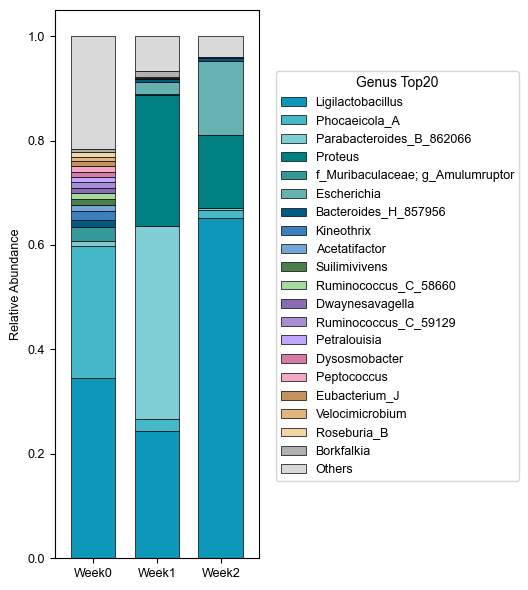

In [19]:
## Genus Level - Top 20

df_barplot.plot(kind='bar', stacked=True,figsize=(5.5, 6), colormap=microbiome20, edgecolor='k', linewidth=0.5, width=0.7)  ## Pastel1은 9개 색 제공 -> 그 이상은 색깔 돌려막기
plt.xticks(ticks=range(len(df_barplot.index)), labels=['Week0', 'Week1', 'Week2'], rotation=0, fontsize=9)  #Edit: plot에 표시될 이름으로 labels 지정
plt.yticks(fontsize=9)
plt.xlabel('')
plt.ylabel('Relative Abundance', fontsize=9)  #Edit
plt.title('')
plt.legend(title='Genus Top20', bbox_to_anchor=(1.05, 0.9), fontsize=9)  #Edit: legend 위치에 맞춰서 조정
plt.tight_layout()
#plt.savefig('weeks_genus_rel_top20.tiff', dpi=300, bbox_inches='tight')
plt.show()